In [5]:
import pandas as pd
import numpy as np
import os
import json

In [6]:
model_dir = './models_output_json'

In [7]:
def load_data(trace_log_dir):
  trace_log = []
  folder = trace_log_dir
  # the list of the json files
  files = os.listdir(folder)
  # sort the files
  files.sort()

  for file in files:
      # get the date from the file name
      date = file.split('.')[0].split('_')[-1]
      # convert the date from YYYYMMDD to YYYY-MM-DD
      date = '-'.join([date[:4], date[4:6], date[6:]])
      #print('loading data for', date)
      # read the json
      with open(os.path.join(folder, file)) as f:
          data = json.load(f)

      if '_' in data[0]["id"]:
            # Dictionary to store combined weights
            combined_weights = {}
            for stock in data:
                stock_id = stock["id"].split('_')[0]
                weight = stock["weight"]
                if stock_id in combined_weights:
                    combined_weights[stock_id] += weight
                else:
                    combined_weights[stock_id] = weight
            # Convert the dictionary back to a list of dictionaries
            data = [{"id": stock_id, "weight": weight} for stock_id, weight in combined_weights.items()]

      # extract the weights
      trace_log.append(
          {
              "date": date,
              "weights": data
          }
      )
  return trace_log


In [ ]:
# enumerate the directories under model_dir
# only load the directories , exclude the files
dirs = os.listdir(model_dir)
dirs = [d for d in dirs if os.path.isdir(os.path.join(model_dir, d))]

dirs.sort()

dirs

NameError: name 'dirs' is not defined

In [ ]:
all_model_logs = {}
for dir in dirs:
    trace_log = []
    trace_log_dir = os.path.join(model_dir, dir)
    trace_log = load_data(trace_log_dir)
    all_model_logs[dir] = trace_log

In [ ]:
unique_ids = set()
for model, trace_log in all_model_logs.items():
    for entry in trace_log:
        for stock in entry["weights"]:
            # not __CASH__
            if stock["id"] == "__CASH__":
                continue
            unique_ids.add(stock["id"])
            

In [ ]:
unique_ids

{'600028.SS',
 '600031.SS',
 '600111.SS',
 '600150.SS',
 '600276.SS',
 '600406.SS',
 '600436.SS',
 '600438.SS',
 '600519.SS',
 '600900.SS',
 '601088.SS',
 '601225.SS',
 '601669.SS',
 'AAL',
 'ABBV',
 'ABNB',
 'ABT',
 'ACGL',
 'ACN',
 'AEP',
 'AIG',
 'AIR.PA',
 'AJG',
 'AKAM',
 'ALB',
 'ALGN',
 'ALLE',
 'ALO.PA',
 'AMAT',
 'AMD',
 'AMZN',
 'ANTO.L',
 'AON',
 'APA',
 'APTV',
 'ARE',
 'ARM',
 'AVGO',
 'AXON',
 'AZN.L',
 'AZO',
 'BA',
 'BA.L',
 'BARC.L',
 'BAYN.DE',
 'BDX',
 'BEI.DE',
 'BEZ.L',
 'BIIB',
 'BKG.L',
 'BKNG',
 'BLDR',
 'BNR.DE',
 'BOL.ST',
 'BR',
 'BRBY.L',
 'BRO',
 'BX',
 'CAH',
 'CAT',
 'CBOE',
 'CBRE',
 'CCH.L',
 'CCI',
 'CDNS',
 'CDW',
 'CE',
 'CI',
 'CL',
 'CMA',
 'CME',
 'CMG',
 'CNA.L',
 'CNC',
 'CNP',
 'CON.DE',
 'COR',
 'COST',
 'CPAY',
 'CPB',
 'CPRT',
 'CRDA.L',
 'CRL',
 'CRM',
 'CTAS',
 'CTRA',
 'CVS',
 'CVX',
 'DCC.L',
 'DECK',
 'DFS',
 'DGE.L',
 'DIS',
 'DLTR',
 'DPLM.L',
 'DTE',
 'DVN',
 'DXCM',
 'ED',
 'EDEN.PA',
 'EL',
 'EL.PA',
 'ELUX-B.ST',
 'ELV',
 'ENPH',


In [ ]:
unique_ids.add('^GSPC')

In [ ]:
import os, datetime
from pandas_datareader import data as pdr
import yfinance as yfin
stocks_data = None
def reload():
    stocks_data = yfin.download(unique_ids, start='2024-05-14', auto_adjust=False, end=None)['Adj Close']
    # save stock_data, do not download again within 24 hours
    stocks_data.to_csv('stocks_data.csv')
    return stocks_data

#stocks_data = yfin.download(list(unique_ids), start='2024-05-14', end=None)['Close']
if os.path.exists('stocks_data.csv'):
    mtime_dt = datetime.datetime.fromtimestamp(os.path.getmtime('stocks_data.csv'))
    now      = datetime.datetime.now()
    diff_sec = (now - mtime_dt).total_seconds()
    if diff_sec < 4 * 3600:
        stocks_data = pd.read_csv('stocks_data.csv', index_col=0, parse_dates=True)
    else:
        stocks_data = reload()

else:
    stocks_data = reload()


[*********************100%***********************]  324 of 324 completed
ERROR	yfinance:multi.py:download()- 
6 Failed downloads:
ERROR	yfinance:multi.py:download()- ['WBA', 'DFS', 'FI', 'PARA', 'CMA', 'HOLX']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-05-14 -> 2026-06-18) (Yahoo error = "No data found, symbol may be delisted")')


In [ ]:
from util import convert, get_currency_pair


for stock_name in list(unique_ids):
  stock_suffix = '.' + stock_name.split('.')[-1]

  exchange_name, needs_inversion, exchange_name_yahoo = get_currency_pair(stock_suffix, 'USD')
  # print(stock_suffix)
  # print(exchange_name)
  if exchange_name is not None:
    print(f'Converting {stock_name} to USD')
    df = stocks_data[[stock_name]]
    if len(df) == 0:
      print(f'No data for {stock_name}')
      continue
    df = df.rename(columns={stock_name: 'Adj Close'})
    df['Volume'] = 0
    df = df.sort_index(ascending=True)
    df = convert(df, exchange_name, needs_inversion, exchange_name_yahoo)
    stocks_data[stock_name] = df['Adj Close']


Converting IAG.L to USD
Metric: DEXUSUK need to be refreshed...
df:
            DEXUSUK
DATE               
1971-01-04   2.3938
1971-01-05   2.3949
1971-01-06   2.3967
1971-01-07   2.3963
1971-01-08   2.3972
...             ...
2026-06-08   1.3347
2026-06-09   1.3389
2026-06-10   1.3392
2026-06-11   1.3337
2026-06-12   1.3414

[14465 rows x 1 columns]
Index(['DEXUSUK'], dtype='object')


[*********************100%***********************]  1 of 1 completed
/home/ken/git/orch/util.py:229: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





df2:
Price          Close      High       Low      Open   Volume
Ticker      GBPUSD=X  GBPUSD=X  GBPUSD=X  GBPUSD=X GBPUSD=X
Date                                                       
2003-12-01  1.718597  1.727205  1.718390  1.723811        0
2003-12-02  1.730313  1.732112  1.717298  1.719010        0
2003-12-03  1.728101  1.731812  1.725209  1.730493        0
2003-12-04  1.720697  1.728997  1.718302  1.727414        0
2003-12-05  1.733102  1.733102  1.719809  1.720608        0
...              ...       ...       ...       ...      ...
2026-06-12  1.341382  1.342642  1.338527  1.341220        0
2026-06-15  1.344972  1.346112  1.341814  1.345316        0
2026-06-16  1.341599  1.344122  1.339160  1.341742        0
2026-06-17  1.342642  1.343544  1.338885  1.342498        0
2026-06-18  1.320463  1.332534  1.319383  1.329628        0

[5862 rows x 5 columns]
MultiIndex([( 'Close', 'GBPUSD=X'),
            (  'High', 'GBPUSD=X'),
            (   'Low', 'GBPUSD=X'),
            (  'Open',

[*********************100%***********************]  1 of 1 completed
/home/ken/git/orch/util.py:229: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





df2:
Price          Close      High       Low      Open Volume
Ticker         SEK=X     SEK=X     SEK=X     SEK=X  SEK=X
Date                                                     
2001-07-16  10.80500  10.81520  10.70230  10.73450      0
2001-07-17  10.72400  10.86120  10.70400  10.82300      0
2001-07-18  10.55980  10.78050  10.55730  10.73280      0
2001-07-19  10.62950  10.67340  10.52200  10.58490      0
2001-07-20  10.65610  10.66800  10.54550  10.57700      0
...              ...       ...       ...       ...    ...
2026-06-12   9.44221   9.47705   9.39410   9.44699      0
2026-06-15   9.38442   9.38825   9.33622   9.37690      0
2026-06-16   9.39687   9.42295   9.35389   9.39559      0
2026-06-17   9.35749   9.40791   9.33927   9.36090      0
2026-06-18   9.50866   9.59186   9.46082   9.49981      0

[6309 rows x 5 columns]
MultiIndex([( 'Close', 'SEK=X'),
            (  'High', 'SEK=X'),
            (   'Low', 'SEK=X'),
            (  'Open', 'SEK=X'),
            ('Volume', 'SE

[*********************100%***********************]  1 of 1 completed
/home/ken/git/orch/util.py:229: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





df2:
Price          Close      High       Low      Open   Volume
Ticker      EURUSD=X  EURUSD=X  EURUSD=X  EURUSD=X EURUSD=X
Date                                                       
2003-12-01  1.196501  1.204007  1.194401  1.203398        0
2003-12-02  1.208897  1.210903  1.194600  1.196101        0
2003-12-03  1.212298  1.213003  1.207700  1.209000        0
2003-12-04  1.208094  1.214403  1.204398  1.212004        0
2003-12-05  1.218695  1.219096  1.206593  1.207802        0
...              ...       ...       ...       ...      ...
2026-06-12  1.157595  1.159152  1.155802  1.157354        0
2026-06-15  1.160308  1.162250  1.159461  1.160645        0
2026-06-16  1.159420  1.161845  1.157541  1.159286        0
2026-06-17  1.160995  1.161845  1.158655  1.160928        0
2026-06-18  1.146132  1.153136  1.145475  1.150748        0

[5850 rows x 5 columns]
MultiIndex([( 'Close', 'EURUSD=X'),
            (  'High', 'EURUSD=X'),
            (   'Low', 'EURUSD=X'),
            (  'Open',

[*********************100%***********************]  1 of 1 completed
/home/ken/git/orch/util.py:229: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





df2:
Price        Close    High     Low    Open Volume
Ticker       CNY=X   CNY=X   CNY=X   CNY=X  CNY=X
Date                                             
2001-06-25  8.2768  8.2868  8.2667  8.2767      0
2001-06-26  8.2768  8.2868  8.2668  8.2768      0
2001-07-02  8.2770  8.2870  8.2667  8.2767      0
2001-07-09  8.2767  8.2868  8.2667  8.2768      0
2001-07-11  8.2769  8.2870  8.2669  8.2769      0
...            ...     ...     ...     ...    ...
2026-06-12  6.7755  6.7755  6.7755  6.7755      0
2026-06-15  6.7660  6.7660  6.7660  6.7660      0
2026-06-16  6.7570  6.7570  6.7570  6.7570      0
2026-06-17  6.7572  6.7572  6.7572  6.7572      0
2026-06-18  6.7681  6.7705  6.7572  6.7572      0

[6252 rows x 5 columns]
MultiIndex([( 'Close', 'CNY=X'),
            (  'High', 'CNY=X'),
            (   'Low', 'CNY=X'),
            (  'Open', 'CNY=X'),
            ('Volume', 'CNY=X')],
           names=['Price', 'Ticker'])
Converting HIK.L to USD
Converting CNA.L to USD
Converting RHM.DE 

In [ ]:
duplicates = stocks_data.index.duplicated()
print(stocks_data.index[duplicates])

DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None)


In [ ]:
import pandas as pd
# Assuming stocks_data is already defined and imported
# Create a range of dates from the minimum to the maximum date in the original DataFrame
stocks_data = stocks_data.sort_index()
all_dates = pd.date_range(start=stocks_data.index.min(), end=stocks_data.index.max(), freq='D')


stocks_data = stocks_data.reindex(all_dates, method='ffill')

In [ ]:
stocks_data.index

DatetimeIndex(['2024-05-14', '2024-05-15', '2024-05-16', '2024-05-17',
               '2024-05-18', '2024-05-19', '2024-05-20', '2024-05-21',
               '2024-05-22', '2024-05-23',
               ...
               '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12',
               '2026-06-13', '2026-06-14', '2026-06-15', '2026-06-16',
               '2026-06-17', '2026-06-18'],
              dtype='datetime64[ns]', length=766, freq='D')

In [ ]:
stocks_data.fillna(method='ffill', inplace=True)
sp500_data = stocks_data['^GSPC']
sp500_data


/tmp/ipykernel_1387401/3351786586.py:1: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



2024-05-14    5246.680176
2024-05-15    5308.149902
2024-05-16    5297.100098
2024-05-17    5303.270020
2024-05-18    5303.270020
                 ...     
2026-06-14    7431.459961
2026-06-15    7554.290039
2026-06-16    7511.350098
2026-06-17    7420.100098
2026-06-18    7500.580078
Freq: D, Name: ^GSPC, Length: 766, dtype: float64

In [ ]:
# remove ^GSPC from stocks_data
stocks_data.drop(columns=['^GSPC'], inplace=True)

# remove ^GSPC from unique_ids
unique_ids.remove('^GSPC')

In [ ]:
len(unique_ids)

323

In [ ]:
sp500_log_return = pd.DataFrame(np.log(sp500_data)).diff()[1:]
log_return = pd.DataFrame(np.log(stocks_data)).diff()[1:]

In [ ]:
log_return = log_return.fillna(0)


In [ ]:
log_return

Ticker,600028.SS,600031.SS,600111.SS,600150.SS,600276.SS,600406.SS,600436.SS,600438.SS,600519.SS,600900.SS,...,WMT,WPP.L,WST,WYNN,XBRANE.ST,XLE,XLK,XLY,XOM,ZTS
2024-05-15,-0.004293,-0.005702,-0.016012,-0.041162,-0.012660,-0.023152,-0.019306,-0.011824,0.000843,-0.001910,...,-0.000501,0.004127,-0.008385,-0.004293,0.041772,0.002239,0.022262,0.001510,0.007704,0.025780
2024-05-16,-0.004626,0.013135,-0.002404,-0.016247,0.000572,-0.023072,-0.002993,-0.000325,0.002768,-0.002233,...,0.067532,0.013186,0.007341,-0.005238,-0.062567,-0.002772,-0.003480,-0.006503,-0.006006,0.002479
2024-05-17,0.005609,0.001041,0.011358,-0.015687,0.000621,0.002317,-0.000045,-0.016576,0.005421,0.013343,...,0.009949,-0.006566,0.004312,-0.000723,-0.031214,0.013891,-0.002216,0.005105,0.014905,0.002013
2024-05-18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-05-19,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-06-15,0.009568,0.014196,0.020319,0.028313,-0.013162,0.008919,-0.008817,-0.010037,-0.016742,-0.025929,...,-0.001819,0.004789,0.007906,-0.012287,0.003158,-0.035371,0.037127,0.016754,-0.042308,0.004764
2026-06-16,-0.002685,-0.027212,0.030811,0.003556,-0.009800,0.004735,-0.019548,-0.003100,-0.010882,-0.012548,...,0.001737,-0.000385,-0.005598,-0.021849,-0.068984,-0.003426,-0.028292,-0.000928,0.006648,-0.007785
2026-06-17,-0.001678,0.013815,-0.032486,0.031693,-0.007662,-0.009419,-0.013206,-0.024759,-0.012588,-0.007042,...,-0.024253,0.007829,-0.018342,-0.013205,0.024002,-0.012542,-0.003439,-0.025391,-0.007926,-0.026440


In [ ]:
# use the date of the first entry in log_return as the start date
start_date = pd.to_datetime(log_return.index[0])


In [ ]:
def update_weight(weights_attr, unique_ids):
  weights = np.zeros(len(unique_ids))
  for asset in weights_attr:
    asset_id = asset['id']
    if asset_id not in unique_ids:
      continue
    asset_weight = asset['weight']
    if 'operation' in asset:
      direction = asset['operation']
      if direction == 'short' and asset_weight > 0:
        asset_weight = -asset_weight
    asset_index = sorted(unique_ids).index(asset_id)
    weights[asset_index] = asset_weight
  return weights

In [ ]:

# for each model, check its first log, use the date as its start
# at start the model's asset is same as the sp500, then for each date, calculate the model's daily return and update the model's asset





model_asset_hists = {k: [1] for k in all_model_logs.keys()}
model_cur_weights = {k: np.zeros(len(unique_ids)) for k in all_model_logs.keys()}
model_daily_return_details = {k: [] for k in all_model_logs.keys()}
for date in log_return.index:
    date_str = str(date.date())
    for model, trace_log in all_model_logs.items():
        
        if pd.to_datetime(trace_log[0]['date']) > date:
            # the model is not started, use sp500's return to update the model's asset
            daily_log_return = sp500_log_return.loc[date_str].values[0]
            model_daily_return = daily_log_return
            cur_asset = model_asset_hists[model][-1] * np.exp(model_daily_return)
            model_asset_hists[model].append(cur_asset)
        else:
            weights = model_cur_weights[model]
            for entry in trace_log:
                if entry['date'] == date_str:
                    weights_attr = entry['weights']
                    weights = update_weight(weights_attr, unique_ids)
                    
                    model_cur_weights[model] = weights
                #print(f'Model: {model}, Date: {date_str}, Weights: {weights}')

            daily_log_return = log_return.loc[date_str].values
            model_daily_return = np.dot(weights, daily_log_return)
            cur_asset = model_asset_hists[model][-1] * np.exp(model_daily_return)
            model_asset_hists[model].append(cur_asset)

            daily_return_details = weights * daily_log_return
            model_daily_return_details[model].append(daily_return_details)

            

        


    

In [ ]:
len(daily_log_return)

323

In [ ]:
model_daily_return_details['NEAT_62']

[array([-0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.94449013e-04,
         0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -4.70027737e-04, -0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.0

In [ ]:
def show_model_return_details(model_name, unique_ids, past_days=5):
    #  during the most recent past days, find out the tickers with most return and loss

    if model_name not in model_daily_return_details:
        print(f'Model {model_name} not found.')
        return
    
    details = model_daily_return_details[model_name]
    recent_details = details[-past_days:]
    avg_return = np.mean(recent_details, axis=0)
    return_df = pd.DataFrame({
        'Ticker': sorted(unique_ids),
        'Average Return': avg_return
    })
    return_df = return_df.sort_values(by='Average Return', ascending=False)
    # take top 5 and bottom 5
    top5    = return_df.head(5)
    bottom5 = return_df.tail(5)

    # concat them (you can reset_index if you like)
    result = pd.concat([top5, bottom5]).reset_index(drop=True)
    return result
    return return_df

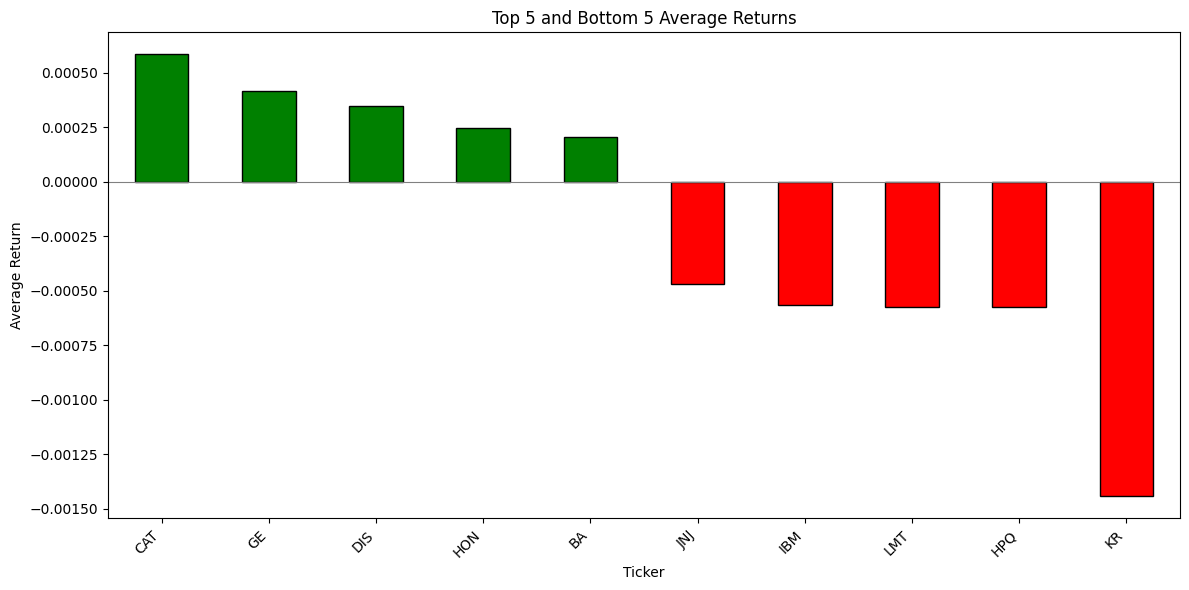

In [ ]:
import matplotlib.pyplot as plt

combined_contrib = show_model_return_details('NEAT_62', unique_ids, past_days=5)
  # Create a bar chart
# 2) BAR CHART
# ------------------
# Make the Ticker column the index, so that pandas will
# use it as our x-axis labels
df = combined_contrib.set_index('Ticker')

# Build a color list from the Average Return
colors = ['green' if x >= 0 else 'red' for x in df['Average Return']]

fig, ax = plt.subplots(figsize=(12, 6))
df['Average Return'].plot(
    kind='bar',
    color=colors,
    ax=ax,
    edgecolor='black'
)

ax.axhline(0, color='gray', linewidth=0.8)            # zero line
ax.set_title('Top 5 and Bottom 5 Average Returns')    # give it a title
ax.set_ylabel('Average Return')                       # y-axis label
ax.set_xlabel('Ticker')                               # x-axis label
plt.xticks(rotation=45, ha='right')                   # rotate tick labels
plt.tight_layout()
plt.show()





In [ ]:
# append the SP500 asset history into model_asset_hists
model_asset_hists['SP500'] = [1]
for date in sp500_log_return.index:
    date_str = str(date.date())
    daily_log_return = sp500_log_return.loc[date_str].values[0]
    model_daily_return = daily_log_return
    cur_asset = model_asset_hists['SP500'][-1] * np.exp(model_daily_return)
    model_asset_hists['SP500'].append(cur_asset)



In [ ]:
def add_vertical_line(fig, date, annotation):
    # draw a line from the bottom (0) to top (1) of the plotting area
    fig.add_shape(
        dict(
            type="line",
            x0=date,
            x1=date,
            y0=0,
            y1=0.9,
            yref="paper",      # span full height
            line=dict(color="blue", width=1),
        )
    )

    # place annotation at the top of the plot
    fig.add_annotation(
        dict(
            x=date,
            y=0.9,
            yref="paper",
            text=annotation,
            showarrow=True,
            arrowhead=2,
            ax=0,
            ay=-40,
            font=dict(size=8),  # shrink the font
        )
    )

In [ ]:
# use plotly to plot the curve of the three assets
import plotly.graph_objects as go

fig = go.Figure()
date_list = log_return.index.tolist()
date_list.insert(0, pd.Timestamp('2024-05-14'))

for model, asset_hist in model_asset_hists.items():
    fig.add_trace(go.Scatter(x=date_list, y=asset_hist, mode='lines', name=model))

fig.update_layout(title='Asset Value Over Time', xaxis_title='Date', yaxis_title='Asset Value')

# Example usage of add_vertical_line function
add_vertical_line(fig, '2024-07-20', 'global selectKBest')
add_vertical_line(fig, '2024-10-10', 'multi-horizon')
add_vertical_line(fig, '2024-11-30', 'Short models')
add_vertical_line(fig, '2026-02-10', 'NEAT_62')
fig.show()